In [1]:
import math
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from matplotlib.artist import Artist
from matplotlib.axes import Axes
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from plotting_defaults import COLOR_MAP, delete_tex_cache, set_style

from fedaugment.utils import cd_to_git_root

cd_to_git_root()
delete_tex_cache()
set_style()

_ = pl.Config.set_tbl_cols(-1)
_ = pl.Config.set_tbl_width_chars(200)
_ = pl.Config.set_float_precision(3)

plots_dir = Path("analysis/plots/augmentations")
plots_dir.mkdir(exist_ok=True, parents=True)

2026-01-28 22:17:40.446 | DEBUG    | fedaugment.utils.misc:cd_to_git_root:154 - Changed working directory to: /home/lbhm/Projects/fedaugment


In [2]:
# Load results per dataset and experiment group
base_path = Path("logs/augmentations")

# Dict: dataset -> experiment_group -> {model_name: df}
results_by_experiment: dict[str, dict[str, dict[str, pl.DataFrame]]] = {}
for dataset_path in base_path.iterdir():
    if not dataset_path.is_dir():
        continue
    dataset = dataset_path.name
    results_by_experiment[dataset] = defaultdict(dict)

    for exp_group_path in dataset_path.iterdir():
        if not exp_group_path.is_dir():
            continue
        exp_group = exp_group_path.name

        for f in exp_group_path.glob("*.csv"):
            if exp_group == "centralized":
                model_name = f.stem.replace("centralized_", "").replace("-dj_adpt", "")
            else:
                model_name = f.stem.split("-")[1]
            results_by_experiment[dataset][exp_group][model_name] = pl.read_csv(f)

    expgroup_str = ", ".join(f"{k}({len(v)})" for k, v in results_by_experiment[dataset].items())
    print(f"{dataset}: {expgroup_str}")

print(f"\nLoaded {len(results_by_experiment)} datasets")

# Simulate a combined OmniMatch dataset
results_by_experiment["omnimatch_both_test"] = defaultdict(dict)

for exp_group, model_dfs in results_by_experiment["omnimatch_city_test"].items():
    for model_name, df_city in model_dfs.items():
        results_by_experiment["omnimatch_both_test"][exp_group][model_name] = pl.concat(
            [df_city, results_by_experiment["omnimatch_culture_test"][exp_group][model_name]]
        )
print("\nAdded omnimatch_both_test dataset")

omnimatch_city_test: centralized(12), all_views(4), 12_views(8)
webtable-union: centralized(8), 08_views(7)
omnimatch_culture_test: centralized(12), all_views(4), 12_views(8)
santos-union: centralized(12), all_views(4), 12_views(8)
freyja: centralized(12), all_views(4), 12_views(8)

Loaded 5 datasets

Added omnimatch_both_test dataset


In [3]:
def gather_centralized_stats(
    centralized_results: dict[str, pl.DataFrame], metric: str, k_vals: list[int]
) -> tuple[dict[int, list[float]], list[float]]:
    """Gather centralized and max recall stats for plotting."""
    model_means_per_k: dict[int, list[float]] = defaultdict(list)
    max_metric_vals: list[float] = []
    for df in centralized_results.values():
        for k in k_vals:
            col = f"{metric}@{k}"
            if col in df.columns:
                model_means_per_k[k].append(df[col].mean())  # pyright: ignore[reportArgumentType]
        if not max_metric_vals:
            max_metric_vals.extend(
                min(1.0, df[f"max_{metric}@{k}"].mean())  # pyright: ignore[reportArgumentType]
                for k in k_vals
            )
    return model_means_per_k, max_metric_vals


def add_centralized_and_max(
    ax: Axes, centralized_results: dict[str, pl.DataFrame], metric: str, k_vals: list[int]
) -> None:
    """Add centralized and max recall lines to the plot."""
    model_means_per_k, max_metric_vals = gather_centralized_stats(
        centralized_results, metric, k_vals
    )
    if any(model_means_per_k.values()):
        all_means = [np.mean(model_means_per_k[k]) for k in k_vals]
        all_mins = [np.min(model_means_per_k[k]) for k in k_vals]
        all_maxs = [np.max(model_means_per_k[k]) for k in k_vals]
        ax.fill_between(k_vals, all_mins, all_maxs, alpha=0.3, color=COLOR_MAP["centralized"])
        ax.plot(k_vals, all_means, color=COLOR_MAP["centralized"])
    if max_metric_vals and len(max_metric_vals) == len(k_vals):
        ax.plot(k_vals, max_metric_vals, "--", color=COLOR_MAP["max_metric"], alpha=0.8)

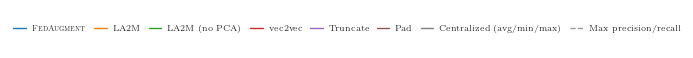

In [4]:
# Handcrafted legend
handles: list[Artist] = [
    Line2D([0], [0], color=COLOR_MAP["cl_optim"], label=r"\system{}"),
    Line2D([0], [0], color=COLOR_MAP["la2m_default"], label="LA2M"),
    Line2D([0], [0], color=COLOR_MAP["la2m_nopca"], label="LA2M (no PCA)"),
    Line2D([0], [0], color=COLOR_MAP["v2v"], label="vec2vec"),
    Line2D([0], [0], color=COLOR_MAP["union_minus"], label="Truncate"),
    Line2D([0], [0], color=COLOR_MAP["union_plus"], label="Pad"),
    Line2D([0], [0], color=COLOR_MAP["centralized"], label="Centralized (avg/min/max)"),
    Line2D(
        [0],
        [0],
        color=COLOR_MAP["max_metric"],
        linestyle="--",
        alpha=0.8,
        label="Max precision/recall",
    ),
]

fig = plt.figure(figsize=(3, 0.5))
legend = plt.legend(handles=handles, loc="center", ncol=len(handles))
legend.axes.axis("off")
fig.canvas.draw()
bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig(plots_dir / "legend.pdf", bbox_inches=bbox)
plt.show()

12_views-freyja


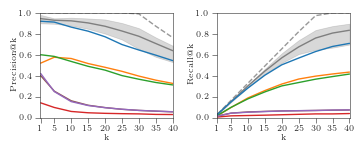

12_views-omnimatch_city_test


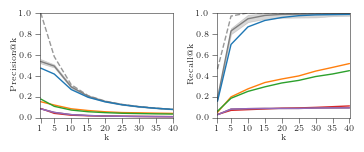

12_views-omnimatch_culture_test


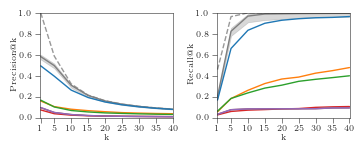

12_views-omnimatch_both_test


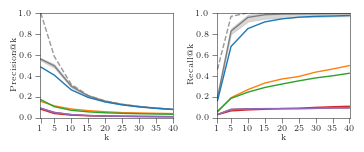

12_views-santos-union


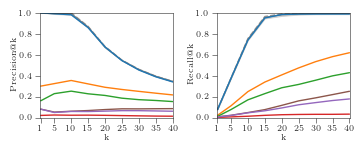

08_views-webtable-union


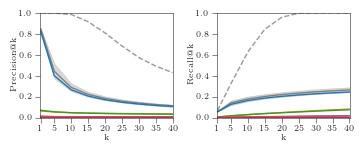

In [5]:
k_vals = [1, 5, 10, 15, 20, 25, 30, 35, 40]
for exp_id, datasets in [
    (
        "12_views",
        [
            "freyja",
            "omnimatch_city_test",
            "omnimatch_culture_test",
            "omnimatch_both_test",
            "santos-union",
        ],
    ),
    ("08_views", ["webtable-union"]),
]:
    for dataset in datasets:
        exp_groups = results_by_experiment[dataset]
        if "centralized" not in exp_groups:
            print(f"{dataset}: skipping, no centralized results")
            continue

        # Max width: 248.08 pt
        fig, axes = plt.subplots(1, 2, figsize=(3.625, 1.5), layout="tight")

        for i, metric in enumerate(["precision", "recall"]):
            ax: Axes = axes[i]
            add_centralized_and_max(ax, exp_groups["centralized"], metric, k_vals)
            for model, df in exp_groups[exp_id].items():
                if model in {"cl_default", "cl_noval"}:
                    continue

                col = f"{metric}@{k_vals[0]}"
                if col not in df.columns:
                    print(f"Metric columns not found: {df.columns}")
                    continue
                means: list[float] = [df[f"{metric}@{k}"].mean() for k in k_vals]  # pyright: ignore[reportAssignmentType]
                ax.plot(k_vals, means, color=COLOR_MAP[model])

            ax.set_xlabel("k")
            ax.set_ylabel(f"{metric.capitalize()}@k")
            ax.set_xticks(k_vals)
            ax.set_xlim(min(k_vals) - 0.1, max(k_vals) + 0.1)
            ax.set_ylim(0, 1)

        fig.savefig(plots_dir / f"{exp_id}-{dataset}.pdf", pad_inches=0.00, bbox_inches="tight")
        print(f"{exp_id}-{dataset}")
        plt.show()

### All Views Analysis

In [6]:
k_vals = [5, 10, 20]

all_views: dict[str, pl.DataFrame] = {}
centralized: dict[str, dict[str, dict[int, list[float]]]] = defaultdict(dict)
for dataset in ["freyja", "omnimatch_city_test", "omnimatch_culture_test", "santos-union"]:
    df_list = []
    for ckpt_name in (base_path / dataset / "all_views").iterdir():
        ckpt_params = ckpt_name.stem.split("-")
        model_name = ckpt_params[1]
        n_views = ckpt_params[2].split("=")[1]
        df = pl.read_csv(ckpt_name).with_columns(
            pl.lit(model_name).alias("model"), pl.lit(int(n_views)).alias("n_views")
        )
        df_list.append(df)

    all_views[dataset] = (
        pl.concat(df_list)
        .group_by(["model", "n_views"])
        .agg(
            [
                pl.col(f"{metric}@{k}").mean().alias(f"{metric}@{k}")
                for metric in ["precision", "recall", "max_precision", "max_recall"]
                for k in k_vals
            ]
        )
    )

    centralized[dataset]["precision"], _ = gather_centralized_stats(
        results_by_experiment[dataset]["centralized"], "precision", k_vals
    )
    centralized[dataset]["recall"], _ = gather_centralized_stats(
        results_by_experiment[dataset]["centralized"], "recall", k_vals
    )

print(f"Loaded {len(all_views)} datasets")

# Simulate a combined OmniMatch dataset
all_views["omnimatch_both_test"] = pl.concat(
    [all_views["omnimatch_city_test"], all_views["omnimatch_culture_test"]]
)
centralized["omnimatch_both_test"]["precision"], _ = gather_centralized_stats(
    results_by_experiment["omnimatch_both_test"]["centralized"], "precision", k_vals
)
centralized["omnimatch_both_test"]["recall"], _ = gather_centralized_stats(
    results_by_experiment["omnimatch_both_test"]["centralized"], "recall", k_vals
)
print("Added omnimatch_both_test dataset")

Loaded 4 datasets
Added omnimatch_both_test dataset


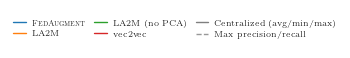

In [7]:
# Handcrafted legend
handles: list[Artist] = [
    Line2D([0], [0], color=COLOR_MAP["cl_optim"], label=r"\system{}"),
    Line2D([0], [0], color=COLOR_MAP["la2m_default"], label="LA2M"),
    Line2D([0], [0], color=COLOR_MAP["la2m_nopca"], label="LA2M (no PCA)"),
    Line2D([0], [0], color=COLOR_MAP["v2v"], label="vec2vec"),
    Line2D([0], [0], color=COLOR_MAP["centralized"], label="Centralized (avg/min/max)"),
    Line2D(
        [0],
        [0],
        color=COLOR_MAP["max_metric"],
        linestyle="--",
        alpha=0.8,
        label="Max precision/recall",
    ),
]

fig = plt.figure(figsize=(3, 0.5))
legend = plt.legend(handles=handles, loc="center", ncol=3)
legend.axes.axis("off")
fig.canvas.draw()
bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig(plots_dir / "all_views-legend.pdf", bbox_inches=bbox)
plt.show()

all_views-freyja-5


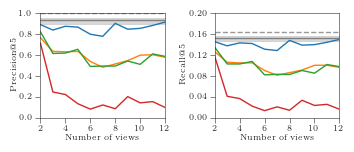

all_views-omnimatch_both_test-5


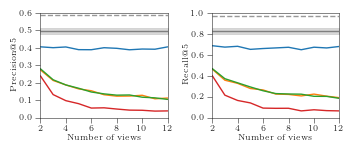

all_views-santos-union-5


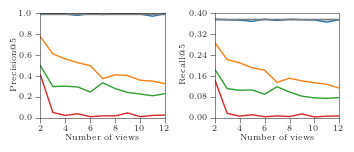

all_views-freyja-10


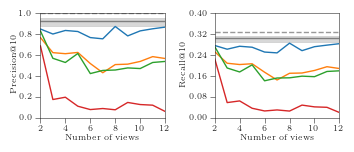

all_views-omnimatch_both_test-10


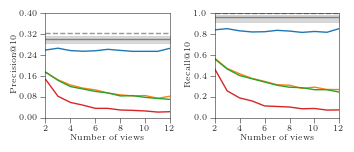

all_views-santos-union-10


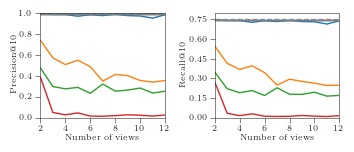

all_views-freyja-20


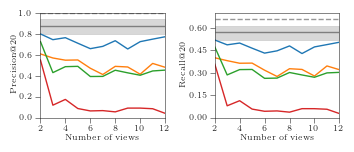

all_views-omnimatch_both_test-20


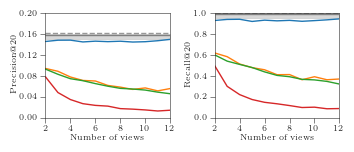

all_views-santos-union-20


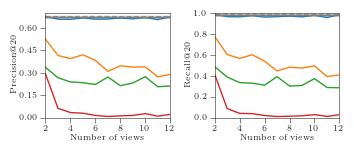

In [8]:
for k in [5, 10, 20]:
    for dataset in ["freyja", "omnimatch_both_test", "santos-union"]:
        df = all_views[dataset]

        # Max width: 241.14 pt
        fig, axes = plt.subplots(1, 2, figsize=(3.525, 1.5), layout="tight")
        min_views: int = df["n_views"].min()  # type: ignore[arg-type]
        max_views: int = df["n_views"].max()  # type: ignore[arg-type]

        for i, metric in enumerate(["precision", "recall"]):
            ax: Axes = axes[i]
            max_metric: float = df[f"max_{metric}@{k}"].max()  # type: ignore[arg-type]
            centralized_metrics = centralized[dataset][metric][k]

            sns.lineplot(
                data=df,
                x="n_views",
                y=f"{metric}@{k}",
                hue="model",
                palette=COLOR_MAP,
                errorbar=None,
                legend=False,
                ax=ax,
            )
            ax.hlines(
                y=max_metric,
                xmin=min_views,
                xmax=max_views,
                linestyles="--",
                colors=COLOR_MAP["max_metric"],
                alpha=0.8,
            )
            ax.hlines(
                y=np.mean(centralized_metrics),
                xmin=min_views,
                xmax=max_views,
                colors=COLOR_MAP["centralized"],
            )
            ax.fill_between(
                x=[min_views, max_views],
                y1=min(centralized_metrics),
                y2=max(centralized_metrics),
                color=COLOR_MAP["centralized"],
                alpha=0.3,
            )

            ax.set_xlabel("Number of views")
            ax.set_ylabel(f"{metric.capitalize()}@{k}")
            ax.set_xlim(min_views, max_views)
            ax.set_ylim(0, min(1, math.ceil(max_metric * 10) / 10))
            ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

        fig.savefig(
            plots_dir / f"all_views-{dataset}-{k}.pdf", pad_inches=0.00, bbox_inches="tight"
        )
        print(f"all_views-{dataset}-{k}")
        plt.show()